In [ ]:
from pyspark import SparkContext
from pyspark.sql import SparkSession

spark = SparkSession\
        .builder\
        .master('local[*]')\
        .getOrCreate()
sc = spark.sparkContext

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/Big Data Notebooks/HandsOn_12.1_Clustering
!ls

/content/drive/My Drive/Colab Notebooks/Big Data Notebooks/HandsOn_12.1_Clustering
12.Spark-ClusteringDajiaForbes.ipynb  minute_weather.csv  utils.py


In [ ]:
from pyspark.sql import SQLContext
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
import utils
%matplotlib inline

In [ ]:
#!cp utils.py /content/drive/My Drive/Colab Notebooks/Big Data Notebooks/HandsOn_12.1_Clustering/utils.py
!cp utils.py /content/utils.py

In [ ]:
sqlContext = SQLContext(sc)
df = sqlContext.read.load('/content/drive/My Drive/Colab Notebooks/Big Data Notebooks/HandsOn_12.1_Clustering/minute_weather.csv',
                          format = 'com.databricks.spark.csv',
                          header='true',inferSchema ='true')

/usr/local/lib/python3.10/dist-packages/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


In [ ]:
df.count()

1587257

In [ ]:
filteredDF = df.filter((df.rowID % 10)==0)


In [ ]:
filteredDF.describe().toPandas().transpose()

,0,1,2,3,4
summary,count,mean,stddev,min,max
rowID,158726,793625.0,458203.9375103623,0,1587250
air_pressure,158726,916.830161410252,3.051716552831359,905.0,929.5
air_temp,158726,61.85158915363659,11.833569210641672,31.64,99.5
avg_wind_direction,158680,162.15610032770354,95.27820101905958,0.0,359.0
avg_wind_speed,158680,2.7752148979077376,2.0576239697426337,0.0,31.9
max_wind_direction,158680,163.46214393748426,92.452138538387,0.0,359.0
max_wind_speed,158680,3.4005577262415194,2.4188016208098855,0.1,36.0
min_wind_direction,158680,166.77401688933702,97.44110914784576,0.0,359.0
min_wind_speed,158680,2.1346641038569323,1.7421125052424373,0.0,31.6


In [ ]:
filteredDF.filter(filteredDF.rain_accumulation == 0.0).count()

157812

In [ ]:
filteredDF.filter(filteredDF.rain_duration == 0.0).count()


157237

In [ ]:
workingDF  = filteredDF.drop('rain_accumulation').drop('rain_duration').drop('hpwren_timestamp')

In [ ]:
before = workingDF.count()
workingDF = workingDF.na.drop()
after = workingDF.count()
before - after

46

In [ ]:
workingDF.columns

['rowID',
 'air_pressure',
 'air_temp',
 'avg_wind_direction',
 'avg_wind_speed',
 'max_wind_direction',
 'max_wind_speed',
 'min_wind_direction',
 'min_wind_speed',
 'relative_humidity']

In [ ]:
featuresUsed = ['air_pressure',
 'air_temp',
 'avg_wind_direction',
 'avg_wind_speed',
 'max_wind_direction',
 'max_wind_speed',
 'relative_humidity']
assembler = VectorAssembler(inputCols = featuresUsed, outputCol = 'features_unscaled')
assembled = assembler.transform(workingDF)

In [ ]:
scaler = StandardScaler(inputCol = 'features_unscaled', outputCol = 'features', withStd = True, withMean = True)
scalerModel = scaler.fit(assembled)
scaledData = scalerModel.transform(assembled)

In [ ]:
scaledData = scaledData.select("features","rowID")
elbowest = scaledData.filter((scaledData.rowID % 3)== 0).select("features")
#elbowest.persist()
elbowest.count()

52897

In [ ]:
def elbow(dataframe, clusters):
    wsseList = []
    for k in clusters:
        print(f"Training for cluster size {k}")
        kmeans = KMeans(featuresCol="features", k=k)
        model = kmeans.fit(dataframe)
        wsse = model.summary.trainingCost
        wsseList.append(wsse)
    return wsseList

# Perform clustering
clusters = range(2, 31)
wsseList = elbow(elbowest, clusters)

# Print results
print("WSSE for each cluster size:", wsseList)

Training for cluster size 2
Training for cluster size 3
Training for cluster size 4
Training for cluster size 5
Training for cluster size 6
Training for cluster size 7
Training for cluster size 8
Training for cluster size 9
Training for cluster size 10
Training for cluster size 11
Training for cluster size 12
Training for cluster size 13
Training for cluster size 14
Training for cluster size 15
Training for cluster size 16
Training for cluster size 17
Training for cluster size 18
Training for cluster size 19
Training for cluster size 20
Training for cluster size 21
Training for cluster size 22
Training for cluster size 23
Training for cluster size 24
Training for cluster size 25
Training for cluster size 26
Training for cluster size 27
Training for cluster size 28
Training for cluster size 29
Training for cluster size 30
WSSE for each cluster size: [287755.01507720276, 231218.48251323123, 193359.6847891359, 167034.69872161775, 154705.4233967932, 145851.1762354544, 139884.81356646412, 1

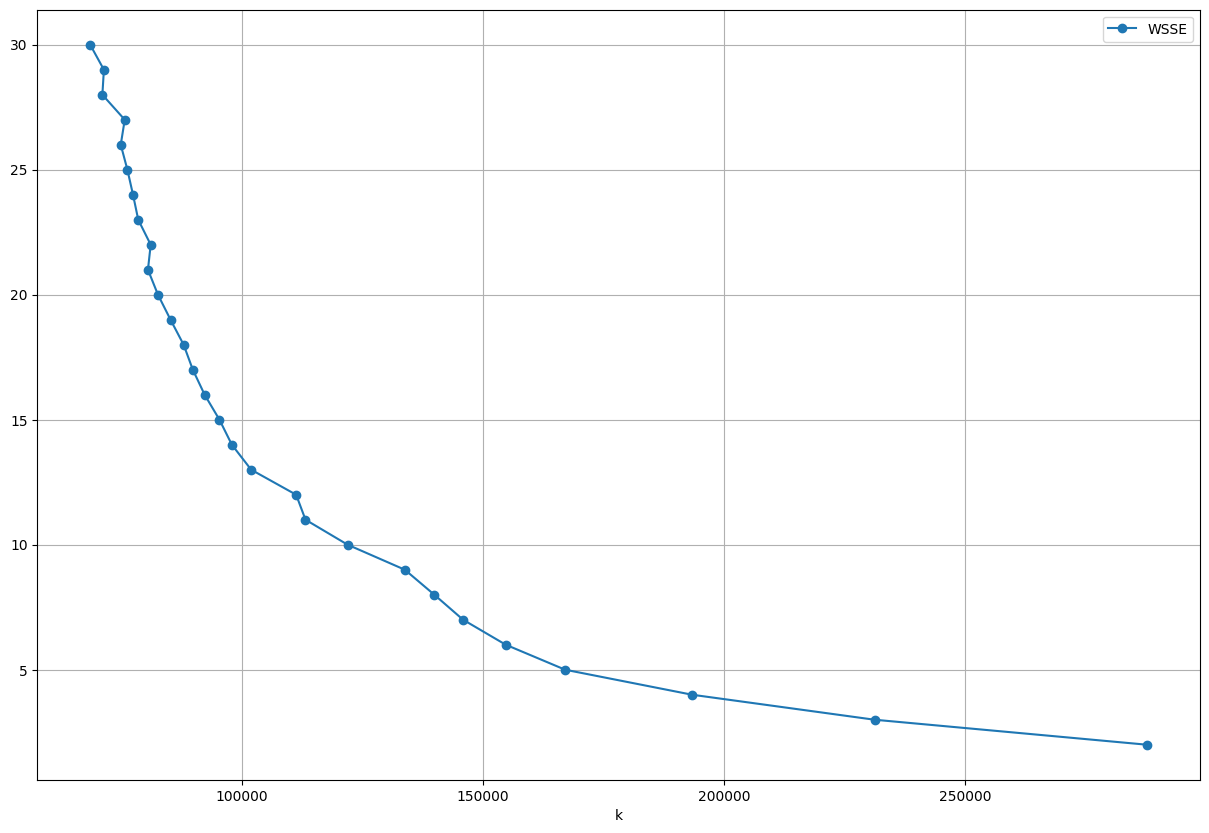

In [ ]:
utils.elbow_plot(clusters, wsseList)

In [ ]:
scaledDataFeat = scaledData.select("features")
scaledDataFeat.persist()


DataFrame[features: vector]

In [ ]:
kmeans = KMeans(k = 12, seed = 1)
model = kmeans.fit(scaledDataFeat)
transformed = model.transform(scaledDataFeat)

In [ ]:
centers = model.clusterCenters()
centers

[array([ 0.31193071, -1.10515968, -1.20684724, -0.5740194 , -1.03920901,
        -0.57936301,  1.07993424]),
 array([ 0.23351408,  0.32066637,  1.88802599, -0.65182056, -1.55151455,
        -0.57651829, -0.2838673 ]),
 array([ 0.30948763,  0.75917911,  1.32559394, -0.63411172,  1.58966255,
        -0.58502263, -0.73899788]),
 array([-0.4338757 ,  0.11613187, -1.17258135, -0.56598772, -1.0498596 ,
        -0.59604043,  0.13662035]),
 array([ 1.44246571, -0.12062683, -1.10201792, -0.09949119, -0.96071048,
        -0.07920465, -0.98449415]),
 array([-1.16139016, -0.83731699,  0.44626299,  1.99066016,  0.5364939 ,
         1.94811864,  0.88038539]),
 array([-0.17202135,  0.61782603,  0.4090396 ,  0.65260512,  0.51893837,
         0.59598055, -0.17946092]),
 array([ 1.18470473, -0.24914106, -1.15442856,  2.09796054, -1.05220352,
         2.21392217, -1.13276907]),
 array([-0.88341971, -1.17891884,  0.37201834,  0.38661636,  0.47274197,
         0.37361112,  1.34268906]),
 array([-0.23216221

In [ ]:
P = utils.pd_centers(featuresUsed, centers)


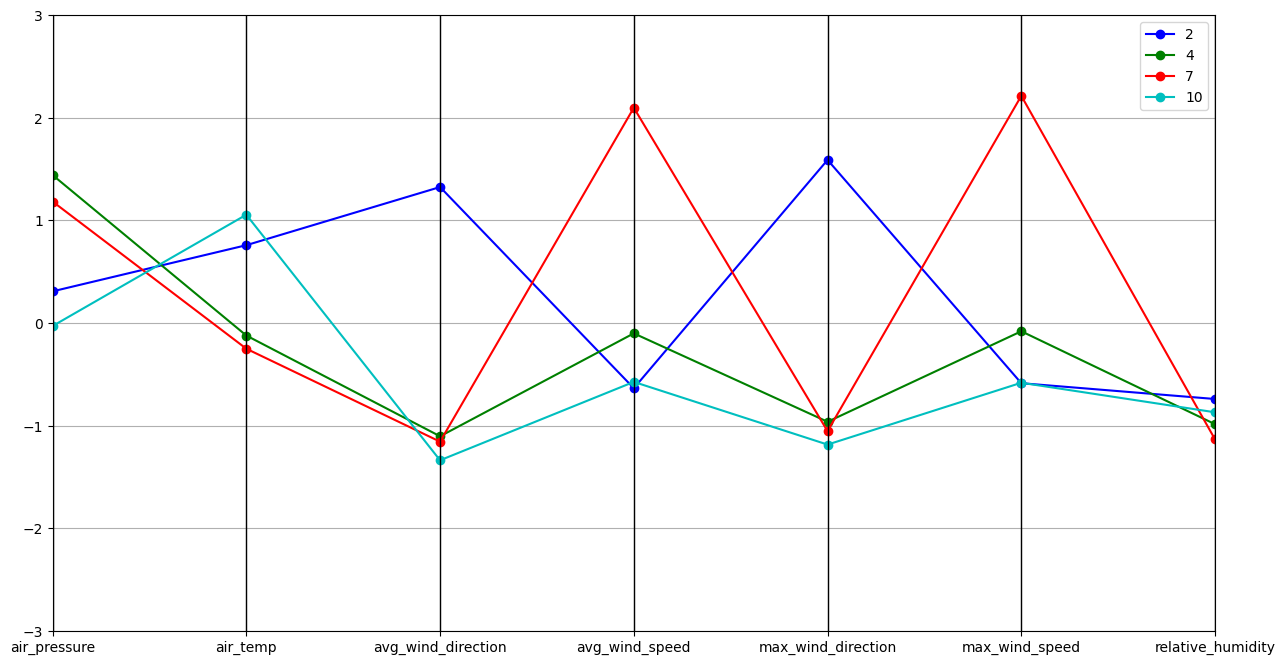

In [ ]:
utils.parallel_plot(P[P['relative_humidity']<-0.5],P)

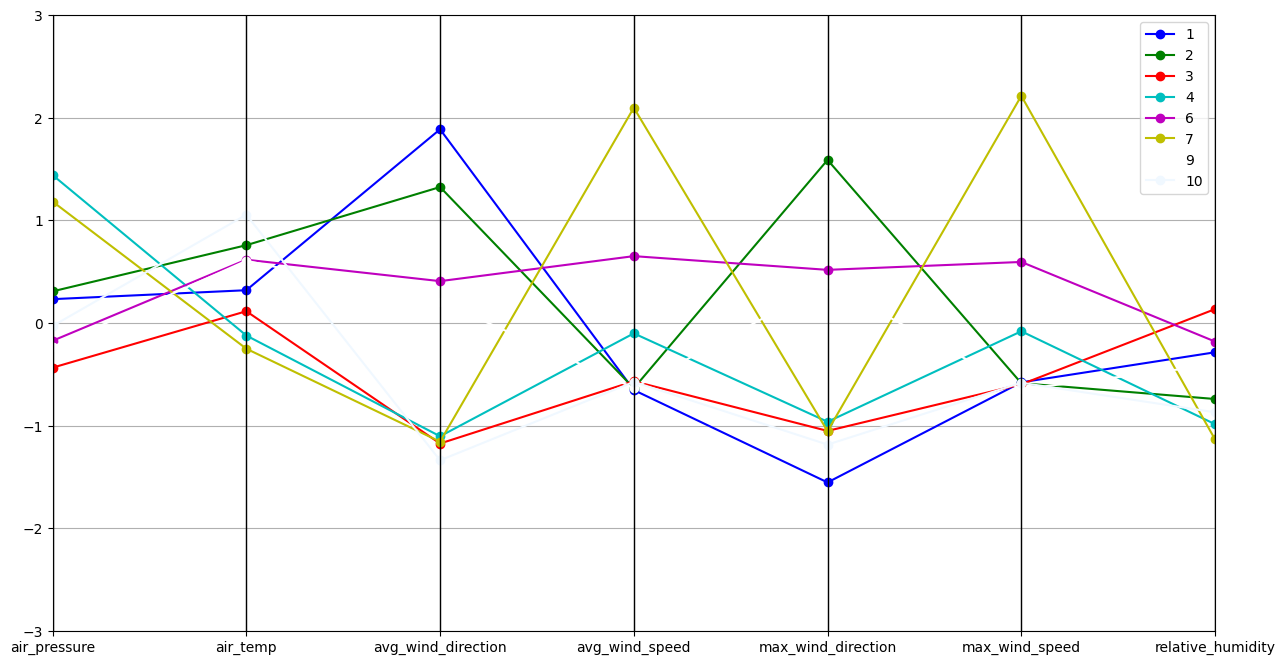

In [ ]:
utils.parallel_plot(P[P['air_temp']> -0.5],P)

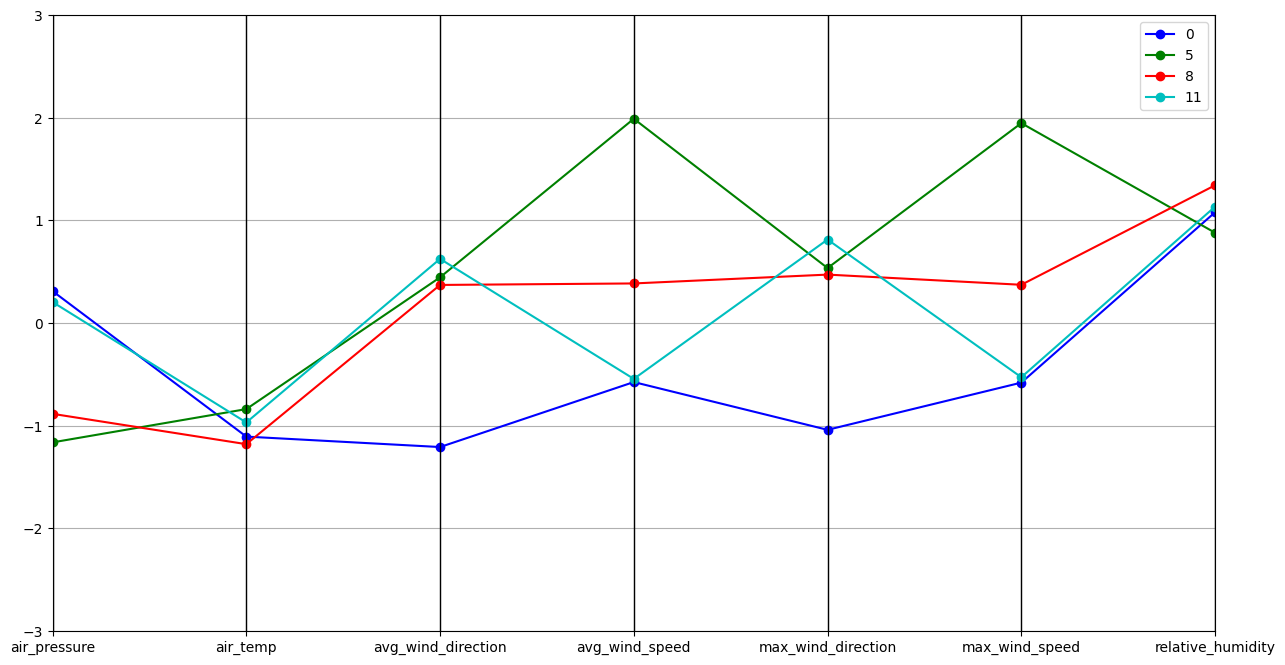

In [ ]:
utils.parallel_plot(P[(P['relative_humidity'] > 0.5) & (P['air_temp'] < 0.5)], P)


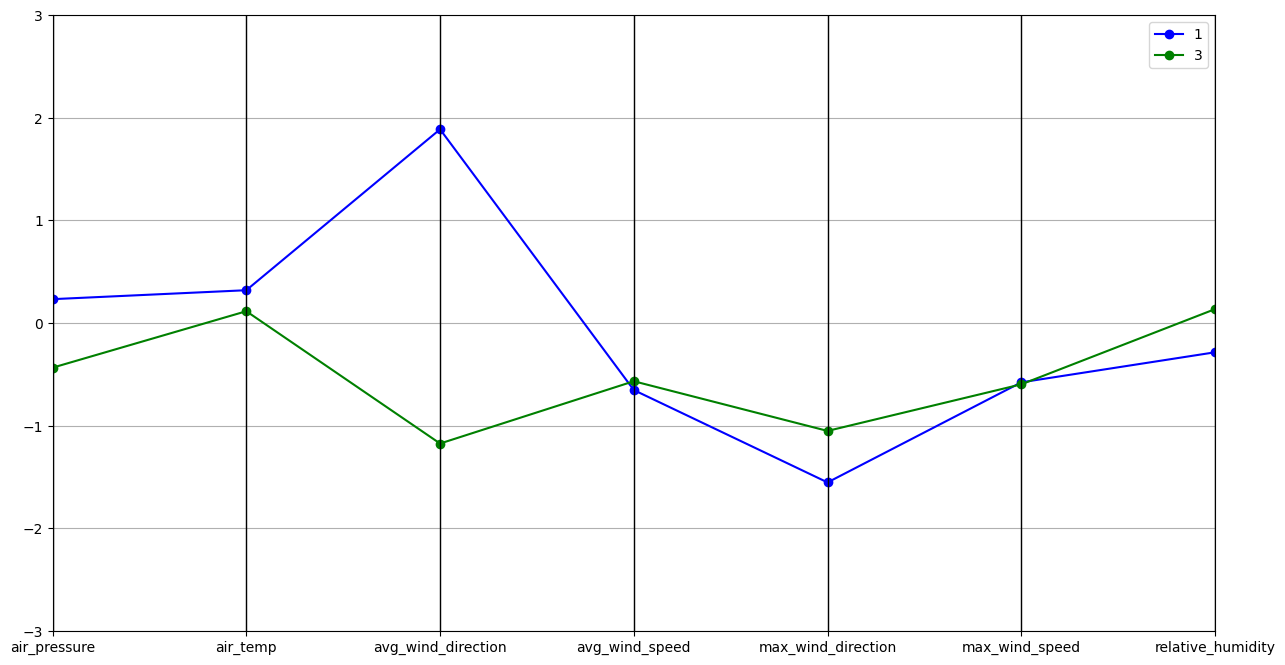

In [ ]:
utils.parallel_plot(P.iloc[[1,3]],P)